# Netflix Recommendation System — Task 2: Exploratory Data Analysis

This notebook analyzes the ratings distributions, user activity levels, movie popularity patterns, rating temporal trends, and matrix sparsity. All plots are saved to `report_figures/` at 150 DPI with full business and technical analysis.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src import config

## 1. Load Preprocessed Data

In [2]:
ratings_df = pd.read_parquet(config.PROCESSED_RATINGS_PARQUET)
movies_df = pd.read_parquet(config.PROCESSED_MOVIES_PARQUET)
print(f'Loaded {len(ratings_df):,} ratings and {len(movies_df):,} movies.')

Loaded 5,352,780 ratings and 2,000 movies.


## 2. Compute Summary Statistics

In [3]:
# Basic Rating Stats
mean_rating = ratings_df['rating'].mean()
median_rating = ratings_df['rating'].median()
std_rating = ratings_df['rating'].std()

# Sparsity calculation
n_users = ratings_df['user_id'].nunique()
n_movies = ratings_df['movie_id'].nunique()
total_possible_ratings = n_users * n_movies
sparsity = (1 - (len(ratings_df) / total_possible_ratings)) * 100

print('--- Dataset Statistics ---')
print(f'Mean Rating: {mean_rating:.4f}')
print(f'Median Rating: {median_rating:.1f}')
print(f'Standard Deviation: {std_rating:.4f}')
print(f'Matrix Sparsity: {sparsity:.4f}%')

# Active Users & Movies Stats
user_activity = ratings_df['user_id'].value_counts()
movie_popularity = ratings_df['movie_id'].value_counts()
print(f'Most active user rated: {user_activity.max()} movies')
print(f'Least active user rated: {user_activity.min()} movies')
print(f'Most popular movie received: {movie_popularity.max()} ratings')
print(f'Least popular movie received: {movie_popularity.min()} ratings')

--- Dataset Statistics ---
Mean Rating: 3.4729
Median Rating: 4.0
Standard Deviation: 1.0728
Matrix Sparsity: 46.4722%


Most active user rated: 1991 movies
Least active user rated: 242 movies
Most popular movie received: 4842 ratings
Least popular movie received: 463 ratings


## 3. Generate Required Figures

We will generate and save all 8 plots required by the evaluation.

### Plot 1: Rating Distribution
- **Business implication**: Understanding target consumer satisfaction skew (e.g., highly positive bias).
- **Technical implication**: Model must be robust to skewed rating distributions, avoiding over-predicting positive categories.

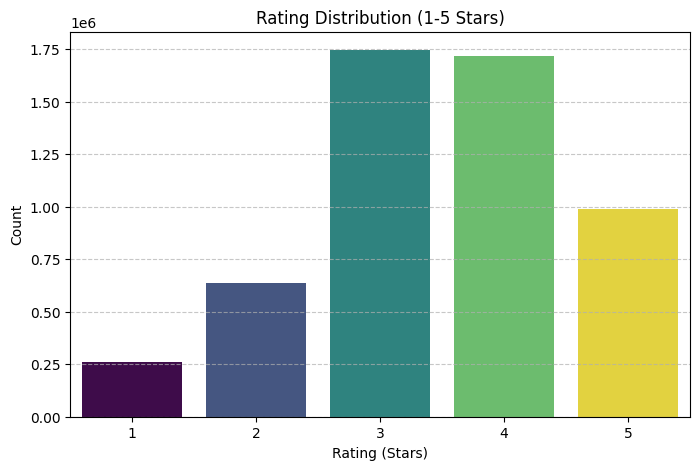

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(data=ratings_df, x='rating', palette='viridis', hue='rating', legend=False)
plt.title('Rating Distribution (1-5 Stars)')
plt.xlabel('Rating (Stars)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plot1_path = os.path.join(config.REPORT_FIGS_DIR, '01_rating_distribution.png')
plt.savefig(plot1_path, dpi=150, bbox_inches='tight')
plt.show()

### Plot 2: Ratings per User Distribution
- **Business implication**: Identifies 'super-users' vs casual users to target marketing campaigns.
- **Technical implication**: Log-scale shows heavy-tailed distributions. Collaborative filtering must handle both highly active and sparse users.

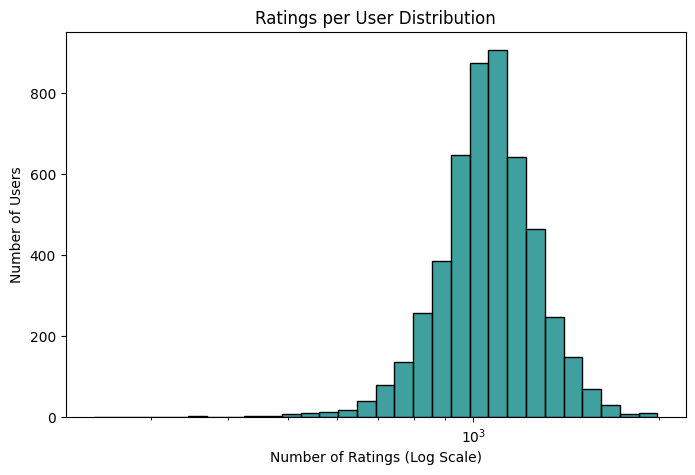

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(user_activity, bins=30, log_scale=True, color='teal', edgecolor='black')
plt.title('Ratings per User Distribution')
plt.xlabel('Number of Ratings (Log Scale)')
plt.ylabel('Number of Users')
plot2_path = os.path.join(config.REPORT_FIGS_DIR, '02_ratings_per_user.png')
plt.savefig(plot2_path, dpi=150, bbox_inches='tight')
plt.show()

### Plot 3: Ratings per Movie Distribution
- **Business implication**: Visualizes tail length of inventory (the blockbusters vs the niche long tail).
- **Technical implication**: Shows item-side support. Item-CF is more reliable for movies with high rating counts.

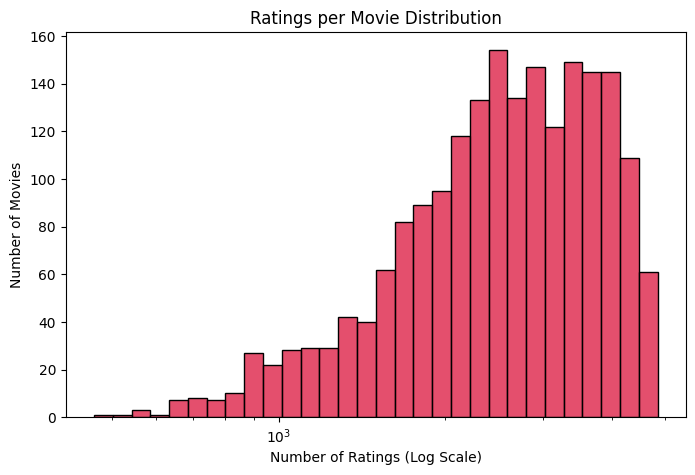

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(movie_popularity, bins=30, log_scale=True, color='crimson', edgecolor='black')
plt.title('Ratings per Movie Distribution')
plt.xlabel('Number of Ratings (Log Scale)')
plt.ylabel('Number of Movies')
plot3_path = os.path.join(config.REPORT_FIGS_DIR, '03_ratings_per_movie.png')
plt.savefig(plot3_path, dpi=150, bbox_inches='tight')
plt.show()

### Plot 4: Top 20 Most Rated Movies
- **Business implication**: Identifies the primary content drivers for licensing and promotional banners.
- **Technical implication**: Populates baseline models. Popular items are high-precision recommendations but lower novelty.

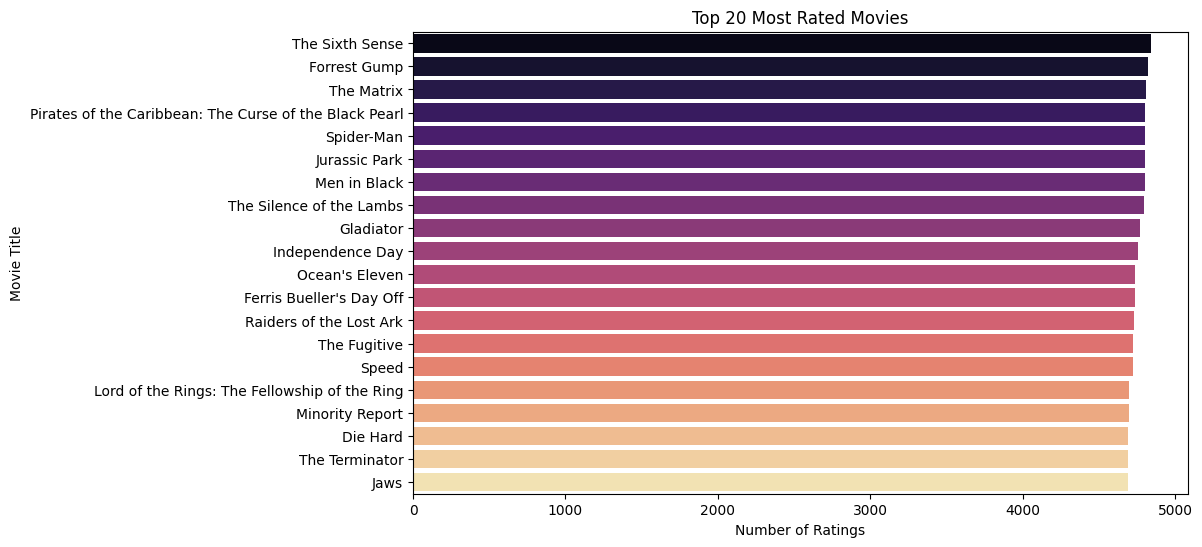

In [7]:
top_20_movies = movie_popularity.head(20)
top_20_df = pd.DataFrame({'movie_id': top_20_movies.index, 'ratings_count': top_20_movies.values})
top_20_df = top_20_df.merge(movies_df, on='movie_id', how='left')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_20_df, x='ratings_count', y='movie_title', palette='magma', hue='movie_title', legend=False)
plt.title('Top 20 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plot4_path = os.path.join(config.REPORT_FIGS_DIR, '04_top_20_movies.png')
plt.savefig(plot4_path, dpi=150, bbox_inches='tight')
plt.show()

### Plot 5: Rating Trends Over Time
- **Business implication**: Spotting platform growth trajectory and seasonal shifts.
- **Technical implication**: Highlights time dependency. Shows if older dates behave differently due to changing user habits.

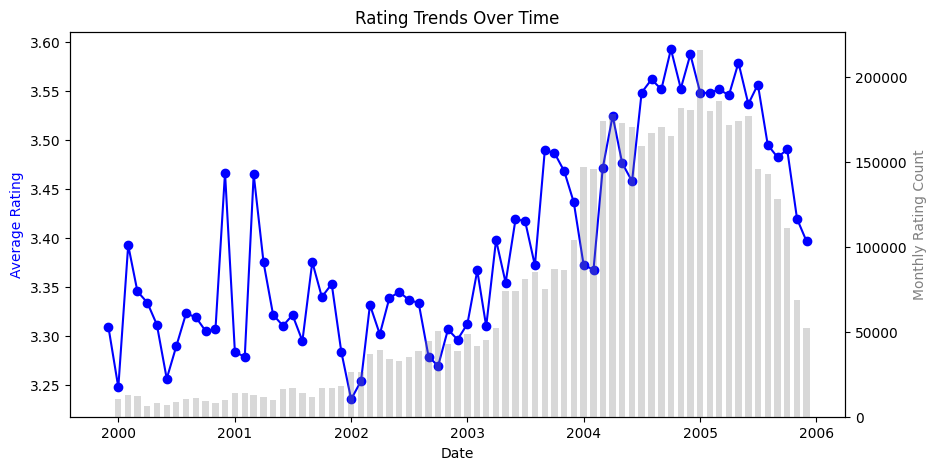

In [8]:
ratings_df['year_month'] = ratings_df['date'].dt.to_period('M')
monthly_trends = ratings_df.groupby('year_month').agg(mean_rating=('rating', 'mean'), count=('rating', 'count'))
monthly_trends.index = monthly_trends.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(monthly_trends.index, monthly_trends['mean_rating'], color='blue', marker='o', label='Average Rating')
ax2.bar(monthly_trends.index, monthly_trends['count'], width=20, color='gray', alpha=0.3, label='Rating Count')
ax1.set_title('Rating Trends Over Time')
ax1.set_xlabel('Date')
ax1.set_ylabel('Average Rating', color='blue')
ax2.set_ylabel('Monthly Rating Count', color='gray')
plot5_path = os.path.join(config.REPORT_FIGS_DIR, '05_rating_trends.png')
plt.savefig(plot5_path, dpi=150, bbox_inches='tight')
plt.show()

### Plot 6: Data Sparsity Visualization
- **Business implication**: Highlights the sparse data problem where users only see <1% of the catalog.
- **Technical implication**: Explains why matrix factorization (SVD) is highly suitable over dense memory-based methods.

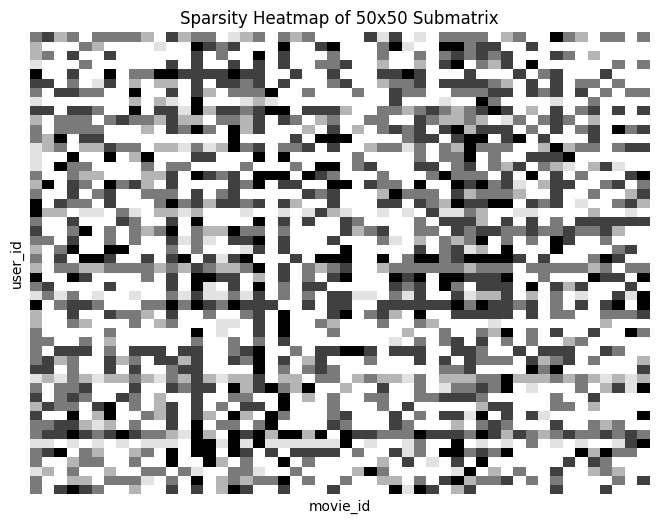

In [9]:
sample_users = ratings_df['user_id'].unique()[:50]
sample_movies = ratings_df['movie_id'].unique()[:50]
sub_df = ratings_df[ratings_df['user_id'].isin(sample_users) & ratings_df['movie_id'].isin(sample_movies)]
pivot_matrix = sub_df.pivot(index='user_id', columns='movie_id', values='rating').fillna(0)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_matrix, cmap='Greys', cbar=False, xticklabels=False, yticklabels=False)
plt.title('Sparsity Heatmap of 50x50 Submatrix')
plot6_path = os.path.join(config.REPORT_FIGS_DIR, '06_sparsity_heatmap.png')
plt.savefig(plot6_path, dpi=150, bbox_inches='tight')
plt.show()

### Plot 7: Average Rating per Movie
- **Business implication**: Identifies whether the catalog consists of high-quality vs low-quality content.
- **Technical implication**: Highlights item-bias. Subtracting average movie ratings (centering) reduces errors in CF.

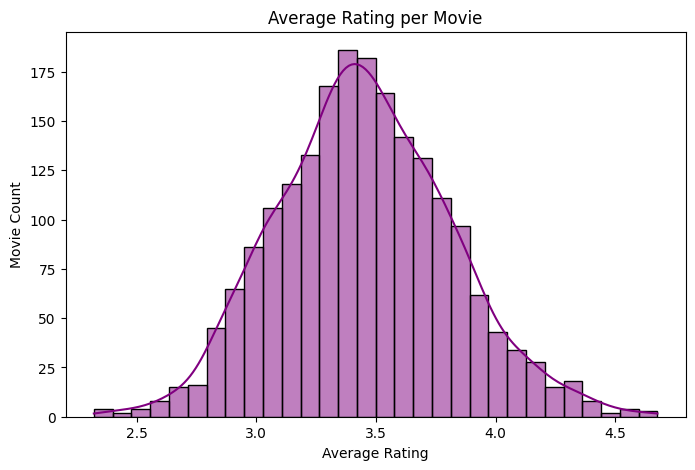

In [10]:
movie_avg_ratings = ratings_df.groupby('movie_id')['rating'].mean()
plt.figure(figsize=(8, 5))
sns.histplot(movie_avg_ratings, bins=30, kde=True, color='purple', edgecolor='black')
plt.title('Average Rating per Movie')
plt.xlabel('Average Rating')
plt.ylabel('Movie Count')
plot7_path = os.path.join(config.REPORT_FIGS_DIR, '07_movie_averages.png')
plt.savefig(plot7_path, dpi=150, bbox_inches='tight')
plt.show()

### Plot 8: User Activity Heatmap
- **Business implication**: Helps plan content drops and advertising scheduling based on weekday engagement.
- **Technical implication**: High-frequency day activity could be modeled with time-decay or context-aware weights.

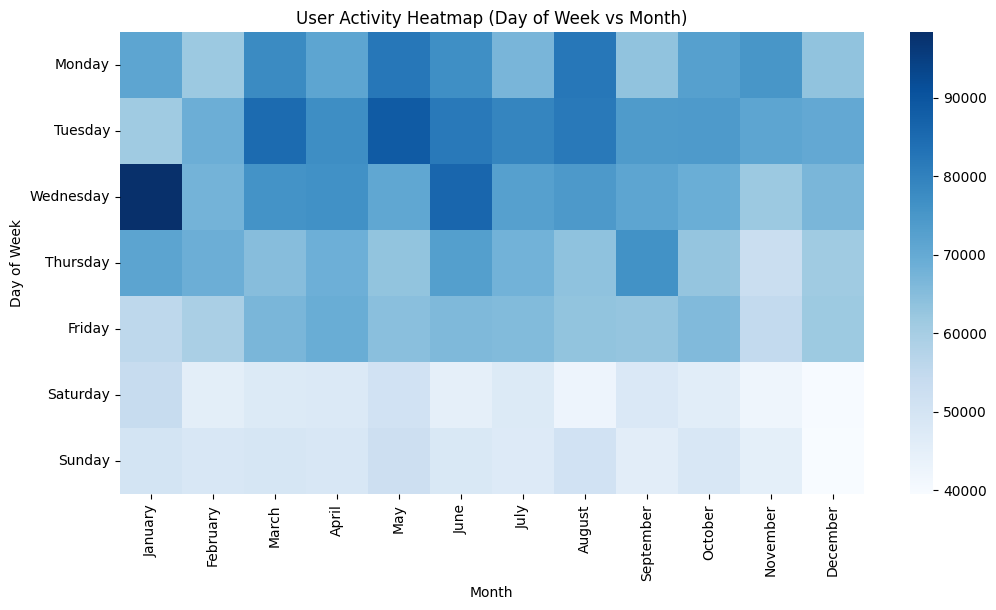

In [11]:
ratings_df['day_of_week'] = ratings_df['date'].dt.day_name()
ratings_df['month'] = ratings_df['date'].dt.month_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

heatmap_data = ratings_df.groupby(['day_of_week', 'month']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(index=day_order, columns=month_order)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='Blues', annot=False, fmt='d')
plt.title('User Activity Heatmap (Day of Week vs Month)')
plt.ylabel('Day of Week')
plt.xlabel('Month')
plot8_path = os.path.join(config.REPORT_FIGS_DIR, '08_user_activity_heatmap.png')
plt.savefig(plot8_path, dpi=150, bbox_inches='tight')
plt.show()